# **# EQAO Math Achievement Analysis (2026)**

# . Executive Summary of Key Initial Findings

# Gender Disparities (Math Overall)
Provincial Standard (Levels 3 & 4):
Male: 56.9% (45.1% Level 3 + 11.8% Level 4)   
PNG
Female: 48.4% (40.9% Level 3 + 7.5% Level 4)   
PNG
Net Gap: Male students have an 8.5 percentage point advantage in meeting/exceeding the provincial standard, with the largest divergence occurring at Level 4 (11.8% vs. 7.5%).   
PNG
Distribution Distribution / "Approaching Standard":
Female students are heavily concentrated at Level 2 (44.3%) compared to males (37.0%).   
PNG
Failure/tail rates are nearly identical between genders: 7.1% total for females at Level 1 / NE1 vs. 6.1% for males.   
PNG
# Language System & Governance Disparities
Provincial Standard Pass Rate (%≥Level 3):
French Public: 65.93%
French Catholic: 62.22%
English Public: 52.25%
English Catholic: 51.22%
Key Observations:
Linguistic Advantage: Students in the French-language system outperform English-language boards by 11 to 14 percentage points.
Governance Dynamics: Public school boards slightly lead Catholic boards in both language sectors (+1.03% in English, +3.71% in French).

# Next Steps:

* Running the Two-Way ANOVA model to formally test Language and Governance interaction effects.
* Disaggregating the results by Grade (Grade == 3 vs. Grade == 6) to see if the gender or language gaps widen as students advance.   
* Conducting the Home Language / ELL analysis (firstlang_other_math) to compare native vs. second-language math performance.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amalmerabti/eqao-g6-math-2026/G36_2026_Aggregate_Field_Definitions.xlsx
/kaggle/input/datasets/amalmerabti/eqao-g6-math-2026/EQAO_G6_2026.xlsx


In [2]:
df = pd.read_excel('/kaggle/input/datasets/amalmerabti/eqao-g6-math-2026/EQAO_G6_2026.xlsx', sheet_name=0)
df.head()

,OrgID,OrgType,Language,Grade,ApplySuppression,BoardMident,BoardName,SchoolMident,SchoolName,FundingType,...,Region,School Number,School Name,Suite,PO Box,Street,City,Province,Postal Code,Date Open
0,19186,S,en,6,1,28010.0,Algoma DSB,19186.0,Anna McCrea PS,1,...,North Region,19186.0,Anna McCrea Public School,NaN,NaN,250 Mark St,Sault Ste Marie,Ontario,P6A3M7,01/09/1969
1,43362,S,en,6,1,28010.0,Algoma DSB,43362.0,Ben R McMullin PS,1,...,North Region,43362.0,Ben R McMullin Public School,NaN,NaN,24 Paradise Ave,Sault Ste Marie,Ontario,P6B5K2,01/09/1969
2,54542,S,en,6,1,28010.0,Algoma DSB,54542.0,Blind River PS,1,...,North Region,54542.0,Blind River Public School,NaN,NaN,19 Hanes Ave,Blind River,Ontario,P0R1B0,01/09/1969
3,490822,S,en,6,1,28010.0,Algoma DSB,490822.0,Boreal French Immersion Public School,1,...,North Region,490822.0,Boreal French Immersion Public School,NaN,NaN,232 Northern Ave,Sault Ste Marie,Ontario,P6B4H6,01/09/1969
4,285552,S,en,6,1,28010.0,Algoma DSB,285552.0,Central Algoma Elementary School,1,...,North Region,285552.0,Central Algoma Public School,NaN,220,5 Margaret St,Desbarats,Ontario,P0R1E0,01/09/1969


In [3]:
# Identify metric columns
metric_cols = [col for col in df.columns if col.startswith('cnt')]

In [4]:
# Convert non-numeric suppression entries to NaN and cast to float
for col in metric_cols:
  df[col] = pd.to_numeric(df[col], errors='coerce')
# Verify the numeric columns
print(df[metric_cols].dtypes)

cntStudents_Math              float64
cntExempted_Math              float64
cntAbsent_Math                float64
cntNoData_Math                float64
cntFullyParticipating_Math    float64
cntFirstLang_Math             float64
cntFirstLang_Other_Math       float64
cntFirstLang_NoData_Math      float64
cntOverallM_L4                float64
cntOverallM_L3                float64
cntOverallM_L2                float64
cntOverallM_L1                float64
cntOverallM_NE1               float64
cntOverallM_L34               float64
cntOverallM_G1_Part           float64
cntOverallM_G1_L4             float64
cntOverallM_G1_L3             float64
cntOverallM_G1_L2             float64
cntOverallM_G1_L1             float64
cntOverallM_G1_NE1            float64
cntOverallM_G1_L34            float64
cntOverallM_G2_Part           float64
cntOverallM_G2_L4             float64
cntOverallM_G2_L3             float64
cntOverallM_G2_L2             float64
cntOverallM_G2_L1             float64
cntOverallM_

In [5]:
# Exporting to CSV for Tableau
output_csv = 'EQAO_Grade6_Math_Combined_Cleaned.csv'

df.to_csv(output_csv, index=False)
print(f'Successfully generated {output_csv}')

Successfully generated EQAO_Grade6_Math_Combined_Cleaned.csv


In [6]:
df.describe()

,OrgID,Grade,ApplySuppression,BoardMident,SchoolMident,Suppressed,cntStudents_Math,cntExempted_Math,cntAbsent_Math,cntNoData_Math,...,cntOverallM_G1_L34,cntOverallM_G2_Part,cntOverallM_G2_L4,cntOverallM_G2_L3,cntOverallM_G2_L2,cntOverallM_G2_L1,cntOverallM_G2_NE1,cntOverallM_G2_L34,_id,School Number
count,3532.000000,3532.0,3532.0,3530.000000,3453.000000,3532.000000,3331.000000,3331.000000,3331.000000,3331.000000,...,2861.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,3413.00000,3413.000000
mean,473491.430351,6.0,1.0,62745.605949,483099.682595,0.068233,128.347944,4.381567,0.238067,1.605824,...,40.465921,70.733382,5.337789,28.945448,31.358020,4.278902,0.813223,34.283237,2913.42426,482900.597129
std,275275.612907,0.0,0.0,11451.284198,270873.866086,0.315086,2372.676995,83.766657,5.051037,32.131232,...,696.637366,1209.359877,88.978740,488.345195,542.957797,75.539344,14.551957,577.126674,1666.09106,271057.061857
min,0.000000,6.0,1.0,15199.000000,78.000000,0.000000,10.000000,0.000000,0.000000,0.000000,...,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.00000,78.000000
25%,225898.000000,6.0,1.0,66052.000000,245038.000000,0.000000,26.000000,0.000000,0.000000,0.000000,...,7.000000,15.000000,0.000000,5.000000,6.000000,0.000000,0.000000,6.000000,1496.00000,244996.000000
50%,487866.000000,6.0,1.0,66141.000000,493816.000000,0.000000,38.000000,1.000000,0.000000,0.000000,...,11.000000,20.000000,1.000000,8.000000,9.000000,1.000000,0.000000,10.000000,2861.00000,493816.000000
75%,744157.750000,6.0,1.0,67067.000000,746568.000000,0.000000,57.000000,2.000000,0.000000,1.000000,...,18.000000,29.000000,3.000000,13.000000,13.000000,2.000000,0.000000,15.000000,4294.00000,746568.000000
max,999992.000000,6.0,1.0,80509.000000,999992.000000,3.000000,134063.000000,4730.000000,274.000000,1796.000000,...,36388.000000,62288.000000,4519.000000,25084.000000,28039.000000,3899.000000,747.000000,29603.000000,5806.00000,874396.000000


In [7]:
df.isnull().sum()

OrgID                            0
OrgType                          0
Language                         0
Grade                            0
ApplySuppression                 0
BoardMident                      2
BoardName                        2
SchoolMident                    79
SchoolName                      79
FundingType                      0
Suppressed                       0
cntStudents_Math               201
cntExempted_Math               201
cntAbsent_Math                 201
cntNoData_Math                 201
cntFullyParticipating_Math     201
cntFirstLang_Math              427
cntFirstLang_Other_Math       2301
cntFirstLang_NoData_Math      3442
cntOverallM_L4                 201
cntOverallM_L3                 201
cntOverallM_L2                 201
cntOverallM_L1                 201
cntOverallM_NE1                201
cntOverallM_L34                201
cntOverallM_G1_Part            671
cntOverallM_G1_L4              671
cntOverallM_G1_L3              671
cntOverallM_G1_L2   

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3532 entries, 0 to 3531
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   OrgID                       3532 non-null   int64  
 1   OrgType                     3532 non-null   object 
 2   Language                    3532 non-null   object 
 3   Grade                       3532 non-null   int64  
 4   ApplySuppression            3532 non-null   int64  
 5   BoardMident                 3530 non-null   float64
 6   BoardName                   3530 non-null   object 
 7   SchoolMident                3453 non-null   float64
 8   SchoolName                  3453 non-null   object 
 9   FundingType                 3532 non-null   object 
 10  Suppressed                  3532 non-null   int64  
 11  cntStudents_Math            3331 non-null   float64
 12  cntExempted_Math            3331 non-null   float64
 13  cntAbsent_Math              3331 

In [9]:
# Renaming columns
rename_dict = {
    # Registration & participation
    'cntStudents_Math': 'students_math',
    'cntExempted_Math': 'exempted_math',
    'cntAbsent_Math': 'absent_math',
    'cntNoData_Math': 'nodata_math',
    'cntFullyParticipating_Math': 'fullyparticipating_math',
    # First language at home
    'cntFirstLang_Math': 'firstlang_math',
    'cntFirstLang_Other_Math': 'firstlang_other_math',
    'cntFirstLang_NoData_Math': 'firstlang_nodata_math',
    # Overall math achievement
    'cntOverallM_L4': 'overall_math_L4',
    'cntOverallM_L3': 'overall_math_L3',
    'cntOverallM_L2': 'overall_math_L2',
    'cntOverallM_L1': 'overall_math_L1',
    'cntOverallM_NE1': 'overall_math_NE1',
    'cntOverallM_L34': 'overall_math_L34',
    # Male students (G1)
    'cntOverallM_G1_Part': 'overall_male_math_part',
    'cntOverallM_G1_L4': 'overall_male_math_L4',
    'cntOverallM_G1_L3': 'overall_male_math_L3',
    'cntOverallM_G1_L2': 'overall_male_math_L2',
    'cntOverallM_G1_L1': 'overall_male_math_L1',
    'cntOverallM_G1_NE1': 'overall_male_math_NE1',
    'cntOverallM_G1_L34': 'overall_male_math_L34',
    # Female students (G2)
    'cntOverallM_G2_Part': 'overall_female_math_part',
    'cntOverallM_G2_L4': 'overall_female_math_L4',
    'cntOverallM_G2_L3': 'overall_female_math_L3',
    'cntOverallM_G2_L2': 'overall_female_math_L2',
    'cntOverallM_G2_L1': 'overall_female_math_L1',
    'cntOverallM_G2_NE1': 'overall_female_math_NE1',
    'cntOverallM_G2_L34': 'overall_female_math_L34',
    # English/French language learners (E1)
    'cntOverallM_E1_Part': 'overall_ell_math_part',
    'cntOverallM_E1_L4': 'overall_ell_math_L4',
    'cntOverallM_E1_L3': 'overall_ell_math_L3',
    'cntOverallM_E1_L2': 'overall_ell_math_L2',
    'cntOverallM_E1_L1': 'overall_ell_math_L1',
    'cntOverallM_E1_NE1': 'overall_ell_math_NE1',
    'cntOverallM_E1_L34': 'overall_ell_math_L34',
    # Special education needs (S1)
    'cntOverallM_S1_Part': 'overall_speced_math_part',
}

# Apply to DataFrame
df.rename(columns=rename_dict, inplace=True)

In [10]:
df.head()

,OrgID,OrgType,Language,Grade,ApplySuppression,BoardMident,BoardName,SchoolMident,SchoolName,FundingType,...,Region,School Number,School Name,Suite,PO Box,Street,City,Province,Postal Code,Date Open
0,19186,S,en,6,1,28010.0,Algoma DSB,19186.0,Anna McCrea PS,1,...,North Region,19186.0,Anna McCrea Public School,NaN,NaN,250 Mark St,Sault Ste Marie,Ontario,P6A3M7,01/09/1969
1,43362,S,en,6,1,28010.0,Algoma DSB,43362.0,Ben R McMullin PS,1,...,North Region,43362.0,Ben R McMullin Public School,NaN,NaN,24 Paradise Ave,Sault Ste Marie,Ontario,P6B5K2,01/09/1969
2,54542,S,en,6,1,28010.0,Algoma DSB,54542.0,Blind River PS,1,...,North Region,54542.0,Blind River Public School,NaN,NaN,19 Hanes Ave,Blind River,Ontario,P0R1B0,01/09/1969
3,490822,S,en,6,1,28010.0,Algoma DSB,490822.0,Boreal French Immersion Public School,1,...,North Region,490822.0,Boreal French Immersion Public School,NaN,NaN,232 Northern Ave,Sault Ste Marie,Ontario,P6B4H6,01/09/1969
4,285552,S,en,6,1,28010.0,Algoma DSB,285552.0,Central Algoma Elementary School,1,...,North Region,285552.0,Central Algoma Public School,NaN,220,5 Margaret St,Desbarats,Ontario,P0R1E0,01/09/1969


In [11]:
output_csv = 'EQAO_Grade6_Math_Cleaned.csv'

df.to_csv(output_csv, index=False)
print(f'Successfully generated {output_csv}')

Successfully generated EQAO_Grade6_Math_Cleaned.csv


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# 1. Identify the 10 level columns
level_cols = [
    'overall_male_math_NE1', 'overall_male_math_L1', 'overall_male_math_L2', 
    'overall_male_math_L3', 'overall_male_math_L4',
    'overall_female_math_NE1', 'overall_female_math_L1', 'overall_female_math_L2', 
    'overall_female_math_L3', 'overall_female_math_L4'
]

# 2. Reshape wide to long (same as Tableau Pivot)
df_melted = df.melt(
    value_vars=level_cols,
    var_name='Subgroup_Level',
    value_name='Student_Count'
)

# 3. Create Gender and Achievement Level columns
df_melted['Gender'] = df_melted['Subgroup_Level'].apply(
    lambda x: 'Female' if 'female' in x.lower() else 'Male'
)

def parse_level(col_name):
    if 'L4' in col_name: return 'Level 4'
    if 'L3' in col_name: return 'Level 3'
    if 'L2' in col_name: return 'Level 2'
    if 'L1' in col_name and 'NE1' not in col_name: return 'Level 1'
    return 'Below Level 1 (NE1)'

df_melted['Achievement_Level'] = df_melted['Subgroup_Level'].apply(parse_level)

In [14]:
# view random sample of erows
df_melted.sample(10, random_state=42)

,Subgroup_Level,Student_Count,Gender,Achievement_Level
18943,overall_female_math_NE1,0.0,Female,Below Level 1 (NE1)
4771,overall_male_math_L1,0.0,Male,Level 1
428,overall_male_math_NE1,0.0,Male,Below Level 1 (NE1)
22177,overall_female_math_L1,1.0,Female,Level 1
6482,overall_male_math_L1,0.0,Male,Level 1
32158,overall_female_math_L4,4.0,Female,Level 4
24689,overall_female_math_L1,1.0,Female,Level 1
4783,overall_male_math_L1,1.0,Male,Level 1
27874,overall_female_math_L2,16.0,Female,Level 2
1758,overall_male_math_NE1,NaN,Male,Below Level 1 (NE1)


In [15]:
# verify mapping with a quick crosstab
pd.crosstab(
    df_melted['Subgroup_Level'], 
    [df_melted['Gender'], df_melted['Achievement_Level']]
)

Gender                               Female                                  \
Achievement_Level       Below Level 1 (NE1) Level 1 Level 2 Level 3 Level 4   
Subgroup_Level                                                                
overall_female_math_L1                    0    3532       0       0       0   
overall_female_math_L2                    0       0    3532       0       0   
overall_female_math_L3                    0       0       0    3532       0   
overall_female_math_L4                    0       0       0       0    3532   
overall_female_math_NE1                3532       0       0       0       0   
overall_male_math_L1                      0       0       0       0       0   
overall_male_math_L2                      0       0       0       0       0   
overall_male_math_L3                      0       0       0       0       0   
overall_male_math_L4                      0       0       0       0       0   
overall_male_math_NE1                     0       0       0       0       0   

Gender                                 Male                                  
Achievement_Level       Below Level 1 (NE1) Level 1 Level 2 Level 3 Level 4  
Subgroup_Level                                                               
overall_female_math_L1                    0       0       0       0       0  
overall_female_math_L2                    0       0       0       0       0  
overall_female_math_L3                    0       0       0       0       0  
overall_female_math_L4                    0       0       0       0       0  
overall_female_math_NE1                   0       0       0       0       0  
overall_male_math_L1                      0    3532       0       0       0  
overall_male_math_L2                      0       0    3532       0       0  
overall_male_math_L3                      0       0       0    3532       0  
overall_male_math_L4                      0       0       0       0    3532  
overall_male_math_NE1                  3532       0       0       0       0

In [16]:
# check nulls and unique category values
print("Unique Genders:", df_melted['Gender'].unique())
print("Unique Levels:", df_melted['Achievement_Level'].unique())
print("\nMissing values per column:\n", df_melted.isnull().sum())

Unique Genders: ['Male' 'Female']
Unique Levels: ['Below Level 1 (NE1)' 'Level 1' 'Level 2' 'Level 3' 'Level 4']

Missing values per column:
 Subgroup_Level          0
Student_Count        7175
Gender                  0
Achievement_Level       0
dtype: int64


In [17]:
# Aggregate total student counts across all schools
summary = (
    df_melted.groupby(['Gender', 'Achievement_Level'])['Student_Count']
    .sum()
    .reset_index()
)

# Calculate percentage within each gender group (sums to 100% per gender)
gender_totals = summary.groupby('Gender')['Student_Count'].transform('sum')
summary['Percentage'] = (summary['Student_Count'] / gender_totals) * 100

# Set explicit level order from lowest to highest
level_order = ['Below Level 1 (NE1)', 'Level 1', 'Level 2', 'Level 3', 'Level 4']

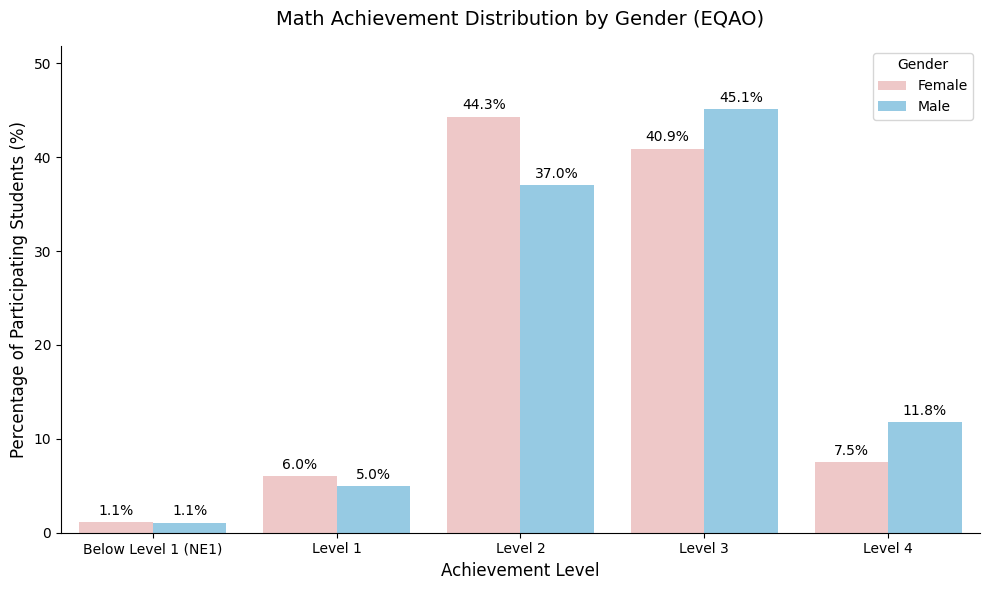

In [18]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=summary,
    x='Achievement_Level',
    y='Percentage',
    hue='Gender',
    order=level_order,
    palette = {'Male': '#89CFF0', 'Female': '#F4C2C2'}
)

# Add percentage labels above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=10,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.title('Math Achievement Distribution by Gender (EQAO)', fontsize=14, pad=15)
plt.xlabel('Achievement Level', fontsize=12)
plt.ylabel('Percentage of Participating Students (%)', fontsize=12)
plt.ylim(0, max(summary['Percentage']) * 1.15)  # Add headroom for labels
plt.legend(title='Gender', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

Provincial Standard (Levels 3 & 4):
Male: 45.1%+11.8%=56.9%
   
Female: 40.9%+7.5%=48.4%
   
This reveals an 8.5 percentage point advantage for male students meeting or exceeding the standard, heavily driven by Level 4 (where boys outnumber girls 11.8% to 7.5%).   
PNG
The "Approaching Standard" Concentration (Level 2):
A massive 44.3% of female students are clustered at Level 2, compared to 37.0% of male students.   
PNG
The lower tails (NE1 and Level 1) are nearly identical (7.1% total for females vs. 6.1% for males). The primary difference is that girls are disproportionately concentrated just below the provincial standard benchmark at Level 2.

In [19]:
# Check unique values in board/school type or language columns
candidate_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['board', 'type', 'lang', 'governance', 'school_type'])]
for col in candidate_cols:
    print(f"--- Column: {col} ---")
    print(df[col].value_counts(dropna=False).head(10))
    print()

--- Column: OrgType ---
OrgType
S    3453
B      77
P       2
Name: count, dtype: int64

--- Column: Language ---
Language
en    3218
fr     314
Name: count, dtype: int64

--- Column: BoardMident ---
BoardMident
66052.0    320
66095.0    183
67059.0    166
66044.0    133
67083.0    128
66060.0    116
66125.0    108
66184.0     98
66176.0     93
66109.0     90
Name: count, dtype: int64

--- Column: BoardName ---
BoardName
Toronto DSB                               320
York Region DSB                           183
Toronto Catholic District School Board    166
Thames Valley District School Board       133
Dufferin-Peel Catholic DSB                128
Durham DSB                                116
Peel District School Board                108
Ottawa-Carleton DSB                        98
Waterloo Region DSB                        93
Simcoe County DSB                          90
Name: count, dtype: int64

--- Column: FundingType ---
FundingType
1        3520
3          10
1 & 3       2
Name: 

In [20]:
# 1. Filter out Board ('B') and Provincial ('P') summary rows to avoid massive double counting
df_schools = df[df['OrgType'] == 'S'].copy()

# 2. System Language: Map 'en' and 'fr' directly
df_schools['System_Language'] = df_schools['Language'].map({'en': 'English', 'fr': 'French'})

# 3. Governance: Identify Catholic vs Public vs Private
def get_governance(row):
    # Check FundingType first (FundingType 3 indicates private/inspected schools in Ontario)
    if str(row.get('FundingType', '')).strip() == '3':
        return 'Private'
    
    board = str(row.get('BoardName', '')).lower()
    if 'catholic' in board or 'catholique' in board:
        return 'Catholic'
    else:
        return 'Public'

df_schools['Governance'] = df_schools.apply(get_governance, axis=1)

# Check the breakdown
print("School Counts by Language and Governance:")
print(pd.crosstab(df_schools['System_Language'], df_schools['Governance'], margins=True))

School Counts by Language and Governance:
Governance       Catholic  Private  Public   All
System_Language                                 
English              1053        6    2094  3153
French                153        2     145   300
All                  1206        8    2239  3453


In [21]:
# Filter to Schools (OrgType == 'S') & Classify Governance
# 1. Filter out Board ('B') and Provincial aggregate ('P') rows
df_schools = df[df['OrgType'] == 'S'].copy()

# 2. Map system language
df_schools['System_Language'] = df_schools['Language'].map({'en': 'English', 'fr': 'French'})

# 3. Classify Governance using FundingType and BoardName
def get_governance(row):
    ft = str(row.get('FundingType', '')).strip()
    
    if ft == '2':
        return 'Private'
    elif ft == '3':
        return 'Provincial School'
    elif ft in ['1', '1 & 3']:
        board = str(row.get('BoardName', '')).lower()
        if 'catholic' in board or 'catholique' in board:
            return 'Catholic'
        return 'Public'
    return 'Other'

df_schools['Governance'] = df_schools.apply(get_governance, axis=1)

# Check the distribution table
print("School Counts by Language and Governance:")
print(pd.crosstab(df_schools['System_Language'], df_schools['Governance'], margins=True))

School Counts by Language and Governance:
Governance       Catholic  Provincial School  Public   All
System_Language                                           
English              1053                  6    2094  3153
French                153                  2     145   300
All                  1206                  8    2239  3453


Because Provincial Schools contain only 8 records and often have heavy data suppression due to small cohorts, filtering to Public and Catholic boards while excluding suppressed records will yield the cleanest comparison.

In [22]:
# 1. Filter out suppressed records (Suppressed != 0 means suppressed or non-participating)
df_clean_schools = df_schools[
    (df_schools['Suppressed'] == 0) & 
    (df_schools['Governance'].isin(['Public', 'Catholic']))
].copy()

print(f"Schools remaining after removing suppressed/provincial: {len(df_clean_schools)}")

Schools remaining after removing suppressed/provincial: 3255


In [23]:
# Melt the 5 Achievement Levels
overall_levels = [
    'overall_math_NE1', 'overall_math_L1', 'overall_math_L2', 
    'overall_math_L3', 'overall_math_L4'
]

# Ensure level columns are numeric (converting any lingering strings/NaNs to 0)
for col in overall_levels:
    df_clean_schools[col] = pd.to_numeric(df_clean_schools[col], errors='coerce').fillna(0)

# Melt wide to long
df_melted_gov = df_clean_schools.melt(
    id_vars=['System_Language', 'Governance'],
    value_vars=overall_levels,
    var_name='Level_Raw',
    value_name='Student_Count'
)

# Standardize achievement level labels
def clean_level(col):
    if 'L4' in col: return 'Level 4'
    if 'L3' in col: return 'Level 3'
    if 'L2' in col: return 'Level 2'
    if 'L1' in col and 'NE1' not in col: return 'Level 1'
    return 'Below Level 1 (NE1)'

df_melted_gov['Achievement_Level'] = df_melted_gov['Level_Raw'].apply(clean_level)

In [24]:
# 1. Aggregate student counts across schools
summary_gov = (
    df_melted_gov.groupby(['System_Language', 'Governance', 'Achievement_Level'])['Student_Count']
    .sum()
    .reset_index()
)

# 2. Calculate percentage within each System Language + Governance cohort (each pair sums to 100%)
group_totals = summary_gov.groupby(['System_Language', 'Governance'])['Student_Count'].transform('sum')
summary_gov['Percentage'] = (summary_gov['Student_Count'] / group_totals) * 100

level_order = ['Below Level 1 (NE1)', 'Level 1', 'Level 2', 'Level 3', 'Level 4']

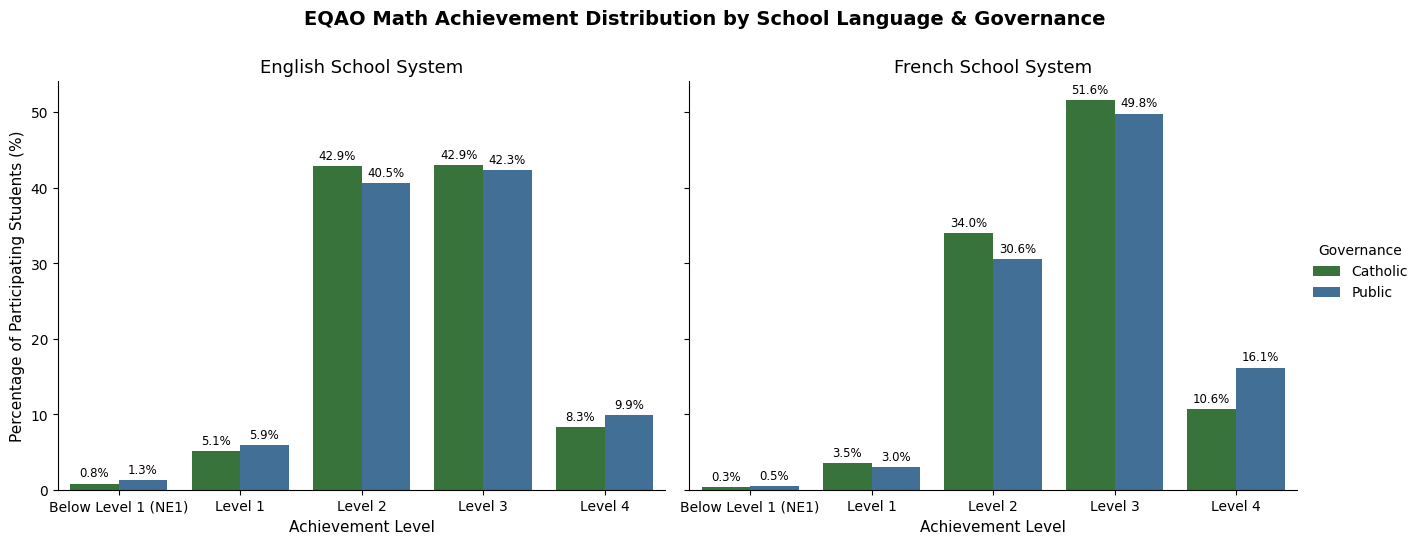

In [25]:
# Palette for Public vs. Catholic
palette = {'Public': '#3470a3', 'Catholic': '#2e7d32'}

g = sns.catplot(
    data=summary_gov,
    x='Achievement_Level',
    y='Percentage',
    hue='Governance',
    col='System_Language',
    kind='bar',
    order=level_order,
    height=5.5,
    aspect=1.2,
    palette=palette
)

g.set_axis_labels('Achievement Level', 'Percentage of Participating Students (%)', fontsize=11)
g.set_titles(col_template='{col_name} School System', size=13)
plt.subplots_adjust(top=0.85)
g.fig.suptitle('EQAO Math Achievement Distribution by School Language & Governance', fontsize=14, weight='bold')

# Add percentage labels above each bar
for ax in g.axes.flat:
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(
                f'{h:.1f}%',
                (p.get_x() + p.get_width() / 2., h),
                ha='center', va='bottom',
                fontsize=8.5, xytext=(0, 3),
                textcoords='offset points'
            )

sns.despine()
plt.show()

In [26]:
# Filter for Level 3 and 4
standard_met = (
    summary_gov[summary_gov['Achievement_Level'].isin(['Level 3', 'Level 4'])]
    .groupby(['System_Language', 'Governance'])['Percentage']
    .sum()
    .round(2)
    .reset_index()
    .rename(columns={'Percentage': 'Met_Standard_Pct (L3+L4)'})
)

print(standard_met)

  System_Language Governance  Met_Standard_Pct (L3+L4)
0         English   Catholic                     51.22
1         English     Public                     52.25
2          French   Catholic                     62.22
3          French     Public                     65.93


**The Linguistic Gap (~11 to 14 percentage points): **
Both French Public (65.93%) and French Catholic (62.22%) outperform English Public (52.25%) and English Catholic (51.22%) by a wide margin. In Ontario, students in the French-language system often come from distinct demographic profiles or high-engagement schooling models, which frequently shows up in provincial benchmarks.
**The Governance Gap (~1 to 3.7 percentage points):**
Within both language systems, Public boards lead Catholic boards by a modest edge (+1.03% in English, +3.71% in French).
Relative Equity in English Boards: Between English Public and English Catholic, performance is remarkably close (52.25% vs. 51.22%), suggesting very similar achievement dynamics across the English-language sector.

Statistical Significance Tests